# Binary Classification with PyCaret - Raisin Classification

This notebook demonstrates a binary classification workflow using PyCaret to classify raisin types.

**Dataset**: Raisin_Dataset.xlsx  
**Target Variable**: Class (Kecimen = 1, Besni = 2)  
**Task**: Predict the type of raisin based on various physical features

## 1. Import Libraries

In [1]:
!pip install pycaret

Defaulting to user installation because normal site-packages is not writeable
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached numpy-1.26.4-cp313-cp313-win_amd64.whl
  Using cached pandas-2.1.4.tar.gz (4.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 2
  ╰─> [126 lines of output]
      + meson setup C:\Users\dhadu\AppData\Local\Temp\pip-install-snj026vp\pandas_7fb4ea6d79ee476eb0aa16db66ff2bad C:\Users\dhadu\AppData\Local\Temp\pip-install-snj026vp\pandas_7fb4ea6d79ee476eb0aa16db66ff2bad\.mesonpy-vbtaqnll\build -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\dhadu\AppData\Local\Temp\pip-install-snj026vp\pandas_7fb4ea6d79ee476eb0aa16db66ff2bad\.mesonpy-vbtaqnll\build\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.1
      Source dir: C:\Users\dhadu\AppData\Local\Temp\pip-install-snj026vp\pandas_7fb4ea6d79ee476eb0aa16db66ff2bad
      Build dir: C:\Users\dhadu\AppData\Local\Temp\pip-install-snj026vp\pandas_7fb4ea6d79ee476eb0aa16db66ff2bad\.mesonpy-vbtaqnll\build
      Build type: native build
      Project name: pandas
      Project version: 2.1.4
   

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from pycaret.classification import *

## 2. Load the Dataset

In [3]:
# Load the raisin dataset
try:
    df = pd.read_excel('Raisin_Dataset.xlsx')
except ImportError:
    # If openpyxl is missing, install it and retry
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"]) 
    df = pd.read_excel('Raisin_Dataset.xlsx')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (900, 8)

First few rows:


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [4]:
df = df.loc[:9999]

## 3. Explore the Data

In [5]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [6]:
# Statistical summary
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


In [7]:
# Check target variable distribution
print("Target Variable Distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Target Variable Distribution:
Class
Kecimen    450
Besni      450
Name: count, dtype: int64

Percentage:
Class
Kecimen    50.0
Besni      50.0
Name: proportion, dtype: float64


In [8]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


## 4. Data Preparation

## 5. Setup PyCaret Environment

This step initializes PyCaret and automatically handles:
- Train/test split
- Data preprocessing
- Feature encoding
- Missing value imputation

In [9]:
# Setup PyCaret classification environment
clf = ClassificationExperiment()
clf.setup(
    data=df,
    target='Class',
    session_id=123,  # For reproducibility
    train_size=0.8,
    normalize=True,
    verbose=True,
    log_experiment=False,  # Disable MLflow logging to avoid compatibility issues
    experiment_name='raisin_classification'
)

,Description,Value
0,Session id,123
1,Target,Class
2,Target type,Binary
3,Target mapping,"Besni: 0, Kecimen: 1"
4,Original data shape,"(900, 8)"
5,Transformed data shape,"(900, 8)"
6,Transformed train set shape,"(720, 8)"
7,Transformed test set shape,"(180, 8)"
8,Numeric features,7
9,Preprocess,True


## 6. Compare Models

PyCaret will train and evaluate multiple classification algorithms automatically

In [10]:
# Compare all available models
best_models = clf.compare_models(n_select=5, sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8694,0.9305,0.8694,0.8725,0.8692,0.7389,0.7419,0.1180
lr,Logistic Regression,0.8653,0.9277,0.8653,0.8684,0.8650,0.7306,0.7337,1.4310
rf,Random Forest Classifier,0.8625,0.9299,0.8625,0.8649,0.8623,0.7250,0.7274,0.1210
knn,K Neighbors Classifier,0.8611,0.9177,0.8611,0.8643,0.8608,0.7222,0.7254,0.0380
ridge,Ridge Classifier,0.8611,0.9258,0.8611,0.8641,0.8608,0.7222,0.7252,0.0260
catboost,CatBoost Classifier,0.8611,0.9333,0.8611,0.8642,0.8608,0.7222,0.7253,1.6830
qda,Quadratic Discriminant Analysis,0.8569,0.9221,0.8569,0.8697,0.8556,0.7139,0.7264,0.0190
lda,Linear Discriminant Analysis,0.8528,0.9260,0.8528,0.8561,0.8525,0.7056,0.7088,0.0240
lightgbm,Light Gradient Boosting Machine,0.8514,0.9238,0.8514,0.8533,0.8512,0.7028,0.7046,0.1600
ada,Ada Boost Classifier,0.8486,0.9126,0.8486,0.8547,0.8479,0.6972,0.7033,0.0650


## 7. Select and Train the Best Model

In [11]:
# Get the best model (top performer)
best_model = best_models[0]
print(f"\nBest Model: {best_model}")


Best Model: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=123, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


## 8. Tune the Best Model

Hyperparameter tuning to optimize model performance

In [12]:
# Tune hyperparameters of the best model
tuned_model = clf.tune_model(best_model, optimize='Accuracy', n_iter=10)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8611,0.9252,0.8611,0.8611,0.8611,0.7222,0.7222
1,0.8472,0.9159,0.8472,0.8497,0.8470,0.6944,0.6969
2,0.8889,0.9213,0.8889,0.8901,0.8888,0.7778,0.7790
3,0.8889,0.8900,0.8889,0.8889,0.8889,0.7778,0.7778
4,0.8889,0.9475,0.8889,0.8938,0.8885,0.7778,0.7826
5,0.8889,0.9730,0.8889,0.9000,0.8881,0.7778,0.7888
6,0.8611,0.9514,0.8611,0.8622,0.8610,0.7222,0.7233
7,0.8750,0.9653,0.8750,0.8897,0.8738,0.7500,0.7646
8,0.8472,0.9059,0.8472,0.8475,0.8472,0.6944,0.6947


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


## 9. Evaluate the Model

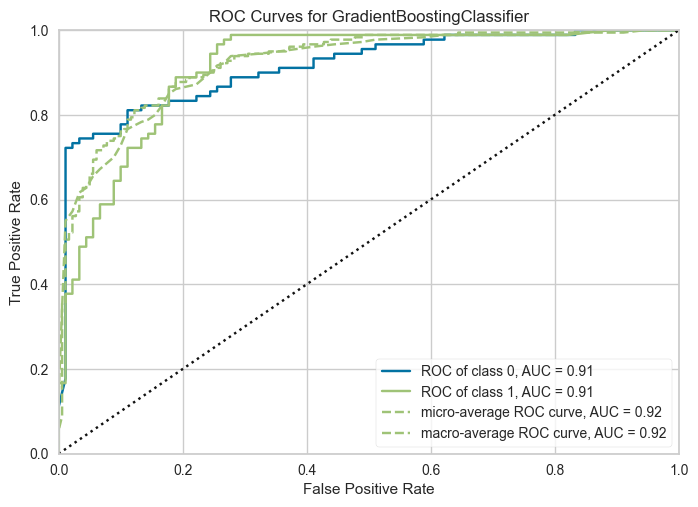

In [13]:
# Plot model performance - AUC curve
clf.plot_model(tuned_model, plot='auc')

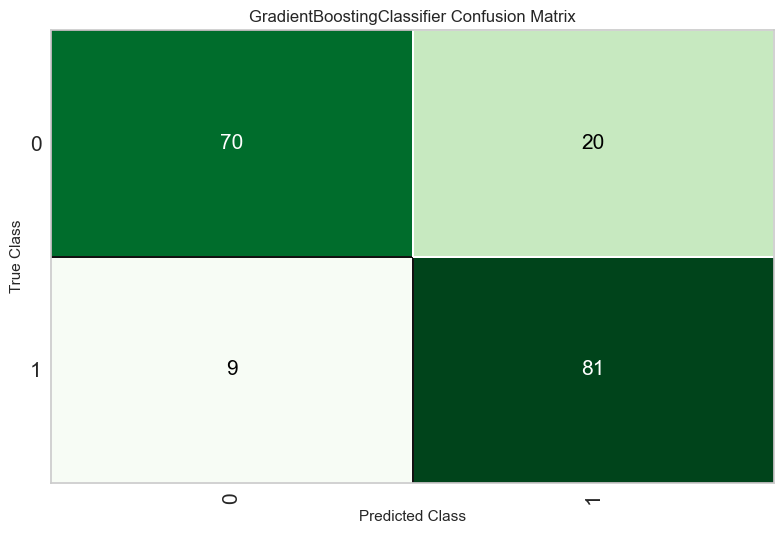

In [14]:
# Plot confusion matrix
clf.plot_model(tuned_model, plot='confusion_matrix')

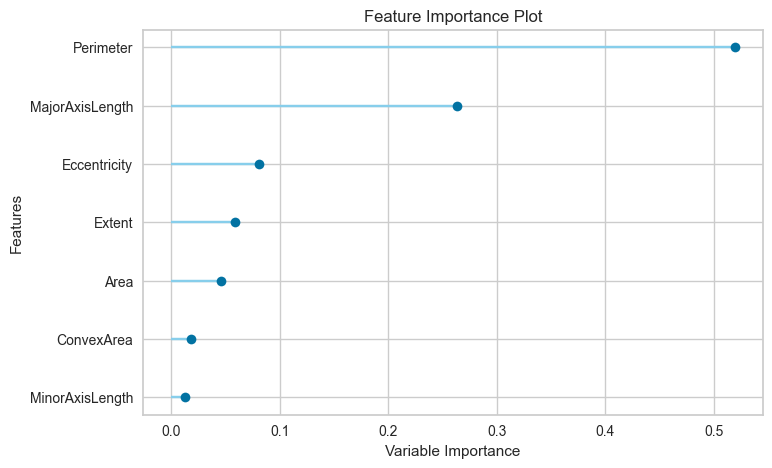

In [15]:
# Plot feature importance
clf.plot_model(tuned_model, plot='feature')

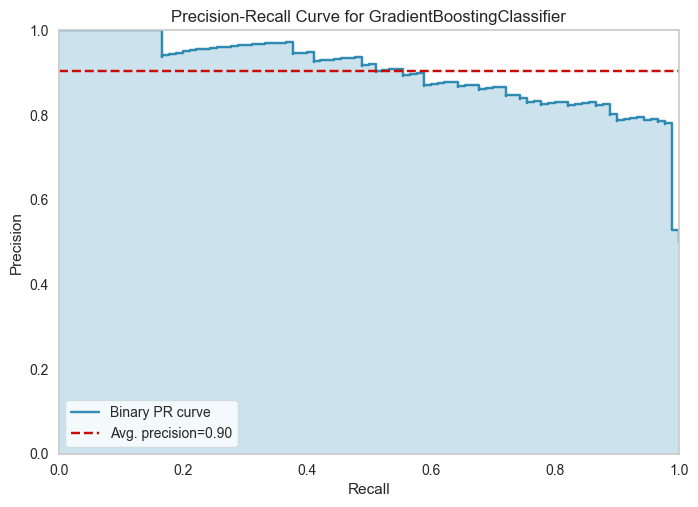

In [16]:
# Plot precision-recall curve
clf.plot_model(tuned_model, plot='pr')

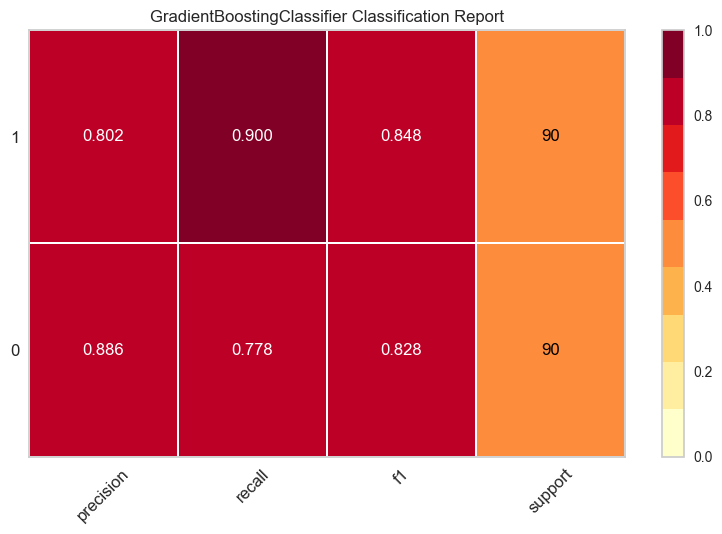

In [17]:
# Plot classification report
clf.plot_model(tuned_model, plot='class_report')

## 10. Make Predictions

In [18]:
# Make predictions on test set
predictions = clf.predict_model(tuned_model)
predictions.head(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8389,0.9133,0.8389,0.8440,0.8383,0.6778,0.6829


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class,prediction_label,prediction_score
585,61444,371.693817,213.179810,0.819180,64321,0.737473,1006.984009,Besni,Kecimen,0.8342
807,78632,407.940338,245.821198,0.798050,79715,0.689011,1068.727051,Besni,Kecimen,0.9707
60,66774,348.557983,246.476257,0.707082,69097,0.692446,1003.374023,Kecimen,Kecimen,0.9205
506,182160,997.291931,271.872406,0.962124,221527,0.379856,2303.689941,Besni,Besni,0.9124
400,49336,338.481476,193.005203,0.821500,52619,0.656553,909.681030,Kecimen,Kecimen,0.8798
231,52693,283.504242,242.113953,0.520265,54860,0.737749,895.744995,Kecimen,Kecimen,0.9704
84,77587,396.807556,251.944916,0.772570,79970,0.703865,1100.836060,Kecimen,Kecimen,0.9460
880,218459,571.289185,492.275269,0.507432,228259,0.731974,1947.459961,Besni,Besni,0.9880
45,57580,330.228363,232.055389,0.711475,60232,0.645103,992.114014,Kecimen,Kecimen,0.8237
72,69006,379.317841,241.850296,0.770374,72895,0.697453,1086.857056,Kecimen,Kecimen,0.8523


## 11. Finalize and Save the Model

In [19]:
# Finalize the model (train on entire dataset)
final_model = clf.finalize_model(tuned_model)
print("Model finalized!")

Model finalized!


In [20]:
# Save the model
clf.save_model(final_model, 'best_raisin_classification_model')
print("Model saved successfully!")

Transformation Pipeline and Model Successfully Saved
Model saved successfully!
Model saved successfully!


## 12. Load and Test the Saved Model (Optional)

In [21]:
# Load the saved model
loaded_model = clf.load_model('best_raisin_classification_model')
print("Model loaded successfully!")

Transformation Pipeline and Model Successfully Loaded
Model loaded successfully!


In [22]:
# Test prediction with sample data
sample_data = df.drop(columns=['Class']).head(5)
sample_predictions = clf.predict_model(loaded_model, data=sample_data)
sample_predictions

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,prediction_label,prediction_score
0,87524,442.246002,253.291153,0.819738,90546,0.758651,1184.040039,Kecimen,0.8121
1,75166,406.690674,243.032440,0.801805,78789,0.684130,1121.786011,Kecimen,0.8037
2,90856,442.267059,266.328308,0.798354,93717,0.637613,1208.574951,Kecimen,0.5188
3,45928,286.540558,208.760040,0.684989,47336,0.699599,844.161987,Kecimen,0.9634
4,79408,352.190765,290.827545,0.564011,81463,0.792772,1073.250977,Kecimen,0.9823


## Summary

In this notebook, we:
1. ✅ Loaded the raisin dataset
2. ✅ Explored the data and checked for issues
3. ✅ Set up PyCaret for binary classification
4. ✅ Compared multiple machine learning models
5. ✅ Tuned the best performing model
6. ✅ Evaluated model performance with various plots
7. ✅ Made predictions on test data
8. ✅ Saved the final model for future use

